# BUSI Breast Cancer Classification — Depthwise Separable CNN

This notebook applies a **Depthwise Separable CNN** architecture to the BUSI (Breast Ultrasound Images) dataset for classifying images as:
- **Normal**
- **Benign**
- **Malignant**

### Why Depthwise Separable Convolutions?
Depthwise Separable Convolutions (used in MobileNet) decompose a standard convolution into:
1. **Depthwise convolution** — applies a single filter per input channel
2. **Pointwise convolution** (1×1 conv) — mixes channels

This reduces parameters and computation by ~8–9×, while often achieving comparable accuracy. It's especially useful for small medical datasets where overfitting is a risk.

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Loading and Preprocessing the Images

In [2]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
base_dir = '/content/drive/MyDrive/BUSI/Dataset_BUSI_with_GT'
classes = ['normal', 'benign', 'malignant']
IMG_SIZE = 128

In [4]:
image_list = []
label_list = []

print("Loading and converting images to arrays...")

for label_idx, class_name in enumerate(classes):
    class_dir = os.path.join(base_dir, class_name)

    if not os.path.exists(class_dir):
        print(f"Warning: Could not find folder {class_dir}")
        continue

    for img_name in os.listdir(class_dir):
        if img_name.endswith('.png') and 'mask' not in img_name:
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                image_list.append(img)
                label_list.append(label_idx)

X = np.array(image_list)
y = np.array(label_list)

print("--- Loading Complete ---")
print(f"Total images loaded: {len(X)}")
print(f"Shape of X data: {X.shape}")
print(f"Class distribution: Normal={np.sum(y==0)}, Benign={np.sum(y==1)}, Malignant={np.sum(y==2)}")

Loading and converting images to arrays...
--- Loading Complete ---
Total images loaded: 780
Shape of X data: (780, 128, 128, 3)
Class distribution: Normal=133, Benign=437, Malignant=210


## 2. Train / Validation / Test Split

In [5]:
# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training samples  : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples      : {len(X_test)}")

Training samples  : 546
Validation samples: 117
Test samples      : 117


## 3. Class Weights (to handle imbalance)

In [6]:
weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: weights_array[0],  # Normal
    1: weights_array[1],  # Benign
    2: weights_array[2]   # Malignant
}

print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(1.956989247311828), 1: np.float64(0.5947712418300654), 2: np.float64(1.2380952380952381)}


## 4. Data Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name='data_augmentation')

## 5. Model Architectures

### Model A — Standard Baseline CNN (for comparison)
Uses regular `Conv2D` layers.

### Model B — Depthwise Separable CNN
Replaces every `Conv2D` with `SeparableConv2D` (depthwise + pointwise). This dramatically reduces the number of trainable parameters while maintaining representational capacity.

**Parameter comparison for a single layer (e.g., 64 filters, 3×3 kernel, 32 input channels):**
- Standard Conv2D  : 3×3×32×64 = **18,432 params**
- SeparableConv2D  : (3×3×32) + (32×64) = 288 + 2,048 = **2,336 params** (~8× fewer)

In [8]:
# ─── Model A: Standard Baseline CNN ───────────────────────────────────────────
def build_baseline_cnn(name='baseline_cnn'):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),

        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(3, activation='softmax')
    ], name=name)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ─── Model B: Depthwise Separable CNN ─────────────────────────────────────────
def build_depthwise_separable_cnn(name='ds_cnn'):
    """
    Mirrors the baseline architecture but replaces Conv2D with SeparableConv2D.
    SeparableConv2D = depthwise convolution  (spatial features per channel)
                    + pointwise convolution  (1x1 conv to mix channels)
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),

        # Block 1
        tf.keras.layers.SeparableConv2D(
            32, (3, 3), activation='relu', padding='same'
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 2
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation='relu', padding='same'
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 3
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation='relu', padding='same'
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 4 — extra depth (cheap thanks to separable convs)
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation='relu', padding='same'
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),   # replaces Flatten — fewer params, less overfit

        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(3, activation='softmax')
    ], name=name)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## 6. Parameter Count Comparison

In [9]:
baseline_temp = build_baseline_cnn()
ds_cnn_temp   = build_depthwise_separable_cnn()

baseline_params = baseline_temp.count_params()
ds_cnn_params   = ds_cnn_temp.count_params()

print("=" * 50)
print(f"Baseline CNN params      : {baseline_params:,}")
print(f"Depthwise Separable CNN  : {ds_cnn_params:,}")
print(f"Reduction factor         : {baseline_params / ds_cnn_params:.2f}×")
print("=" * 50)

print("\n--- Baseline CNN Summary ---")
baseline_temp.summary()
print("\n--- Depthwise Separable CNN Summary ---")
ds_cnn_temp.summary()

del baseline_temp, ds_cnn_temp

Baseline CNN params      : 3,305,027
Depthwise Separable CNN  : 80,830
Reduction factor         : 40.89×

--- Baseline CNN Summary ---


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

...

Model: "ds_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 128, 128, 32)   │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 64, 64, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 16, 16, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,830 (315.74 KB)

 Trainable params: 79,870 (311.99 KB)

 Non-trainable params: 960 (3.75 KB)

## 7. Training — Model A: Baseline CNN (with augmentation)

In [10]:
print("Building Model A (Baseline CNN + Augmentation)...")

model_a = tf.keras.Sequential([
    data_augmentation,
    build_baseline_cnn()
])
model_a.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_a = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
    )
]

print("Starting Training for Model A...")
history_a = model_a.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks_a,
    verbose=1
)
print("--- Model A Training Complete ---")

Building Model A (Baseline CNN + Augmentation)...
Starting Training for Model A...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.4066 - loss: 1.1008 - val_accuracy: 0.5726 - val_loss: 1.0241 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4231 - loss: 1.0852 - val_accuracy: 0.4444 - val_loss: 1.0488 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5733 - loss: 0.9987 - val_accuracy: 0.5470 - val_loss: 0.9751 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4707 - loss: 0.9868 - val_accuracy: 0.6667 - val_loss: 0.8540 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6172 - loss: 0.9541 - val_accuracy: 0.6068 - val_loss: 0.8287 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6044 - loss: 0.8669 - val_accuracy: 0.6923 - val_loss: 0.9555 - learning_rate: 0.0010
Epoch 7/50


## 8. Training — Model B: Depthwise Separable CNN (with augmentation)

In [11]:
print("Building Model B (Depthwise Separable CNN + Augmentation)...")

model_b = tf.keras.Sequential([
    data_augmentation,
    build_depthwise_separable_cnn()
])
model_b.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_b = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
    )
]

print("Starting Training for Model B...")
history_b = model_b.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks_b,
    verbose=1
)
print("--- Model B Training Complete ---")

Building Model B (Depthwise Separable CNN + Augmentation)...
Starting Training for Model B...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.4212 - loss: 1.0562 - val_accuracy: 0.1709 - val_loss: 1.1110 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.4963 - loss: 0.9533 - val_accuracy: 0.1709 - val_loss: 1.1238 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5586 - loss: 0.8800 - val_accuracy: 0.1709 - val_loss: 1.1330 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.6062 - loss: 0.8421 - val_accuracy: 0.1709 - val_loss: 1.1655 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6136 - loss: 0.8111 - val_accuracy: 0.1709 - val_loss: 1.1863 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6282 - loss: 0.7711 - val_accuracy: 0.1709 - val_loss: 1.2172 - learning_rate: 0.0010


## 9. Training Curves Comparison

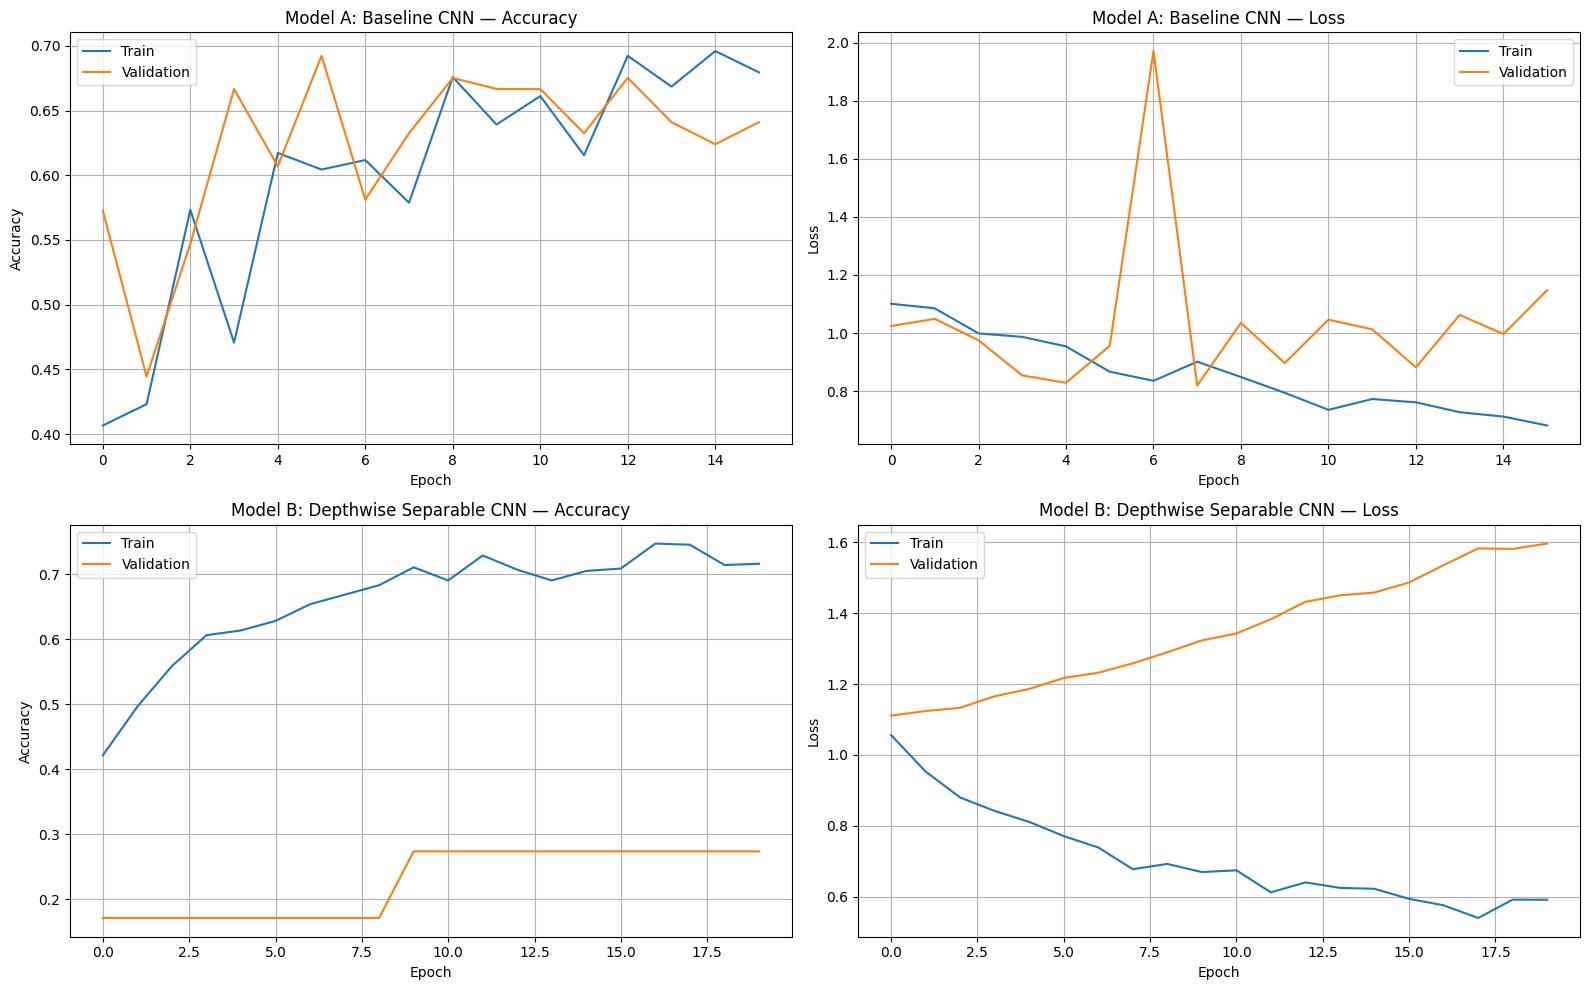

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Accuracy — Model A
axes[0, 0].plot(history_a.history['accuracy'],     label='Train')
axes[0, 0].plot(history_a.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Model A: Baseline CNN — Accuracy')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend(); axes[0, 0].grid(True)

# Loss — Model A
axes[0, 1].plot(history_a.history['loss'],     label='Train')
axes[0, 1].plot(history_a.history['val_loss'], label='Validation')
axes[0, 1].set_title('Model A: Baseline CNN — Loss')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend(); axes[0, 1].grid(True)

# Accuracy — Model B
axes[1, 0].plot(history_b.history['accuracy'],     label='Train')
axes[1, 0].plot(history_b.history['val_accuracy'], label='Validation')
axes[1, 0].set_title('Model B: Depthwise Separable CNN — Accuracy')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend(); axes[1, 0].grid(True)

# Loss — Model B
axes[1, 1].plot(history_b.history['loss'],     label='Train')
axes[1, 1].plot(history_b.history['val_loss'], label='Validation')
axes[1, 1].set_title('Model B: Depthwise Separable CNN — Loss')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 10. Evaluation on Test Set


  TEST RESULTS — Baseline CNN
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Classification Report:
              precision    recall  f1-score   support

      normal       0.19      0.20      0.20        20
      benign       0.64      0.77      0.70        66
   malignant       0.88      0.45      0.60        31

    accuracy                           0.59       117
   macro avg       0.57      0.47      0.50       117
weighted avg       0.62      0.59      0.59       117



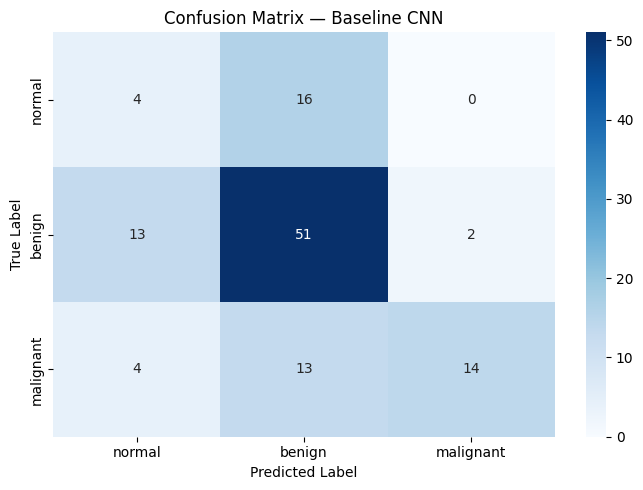


  TEST RESULTS — Depthwise Separable CNN
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

Classification Report:
              precision    recall  f1-score   support

      normal       0.00      0.00      0.00        20
      benign       0.00      0.00      0.00        66
   malignant       0.26      1.00      0.42        31

    accuracy                           0.26       117
   macro avg       0.09      0.33      0.14       117
weighted avg       0.07      0.26      0.11       117



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


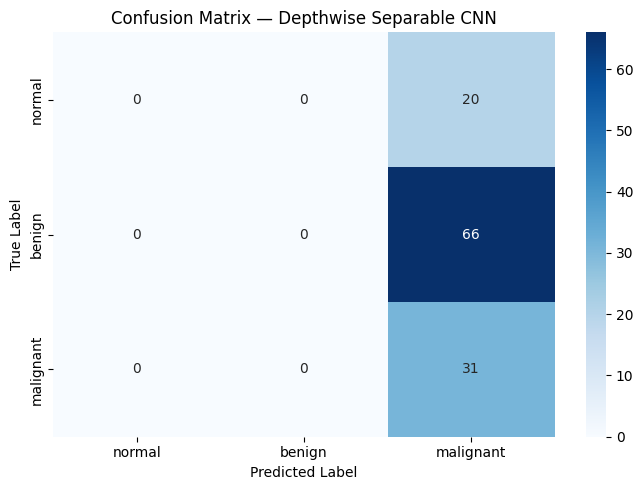

In [13]:
def evaluate_model(model, X_test, y_test, classes, model_name):
    """Print classification report and plot confusion matrix."""
    print(f"\n{'='*55}")
    print(f"  TEST RESULTS — {model_name}")
    print(f"{'='*55}")

    predictions = model.predict(X_test)
    y_pred = np.argmax(predictions, axis=1)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=classes))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()

    return y_pred


y_pred_a = evaluate_model(model_a, X_test, y_test, classes, 'Baseline CNN')
y_pred_b = evaluate_model(model_b, X_test, y_test, classes, 'Depthwise Separable CNN')

## 11. Side-by-Side Metric Comparison

In [14]:
from sklearn.metrics import accuracy_score, f1_score

acc_a  = accuracy_score(y_test, y_pred_a)
acc_b  = accuracy_score(y_test, y_pred_b)
f1_a   = f1_score(y_test, y_pred_a, average='weighted')
f1_b   = f1_score(y_test, y_pred_b, average='weighted')

params_a = model_a.count_params()
params_b = model_b.count_params()

print("\n" + "=" * 60)
print(f"{'Metric':<30} {'Baseline CNN':>12} {'DS-CNN':>12}")
print("-" * 60)
print(f"{'Test Accuracy':<30} {acc_a:>11.4f}  {acc_b:>11.4f}")
print(f"{'Weighted F1 Score':<30} {f1_a:>11.4f}  {f1_b:>11.4f}")
print(f"{'Total Parameters':<30} {params_a:>11,}  {params_b:>11,}")
print(f"{'Param Reduction':<30} {'—':>12} {params_a/params_b:>10.2f}×")
print("=" * 60)

if acc_b >= acc_a:
    print(f"\n✅ Depthwise Separable CNN achieves equal or BETTER accuracy")
    print(f"   with {params_a/params_b:.2f}× fewer parameters!")
else:
    gap = (acc_a - acc_b) * 100
    print(f"\n📌 Depthwise Separable CNN is {gap:.2f}% behind on accuracy")
    print(f"   but uses {params_a/params_b:.2f}× fewer parameters.")


Metric                         Baseline CNN       DS-CNN
------------------------------------------------------------
Test Accuracy                       0.5897       0.2650
Weighted F1 Score                   0.5853       0.1110
Total Parameters                 3,305,027       80,830
Param Reduction                           —      40.89×

📌 Depthwise Separable CNN is 32.48% behind on accuracy
   but uses 40.89× fewer parameters.


## 12. Visualise Misclassified Examples

Total misclassified by DS-CNN: 86 / 117


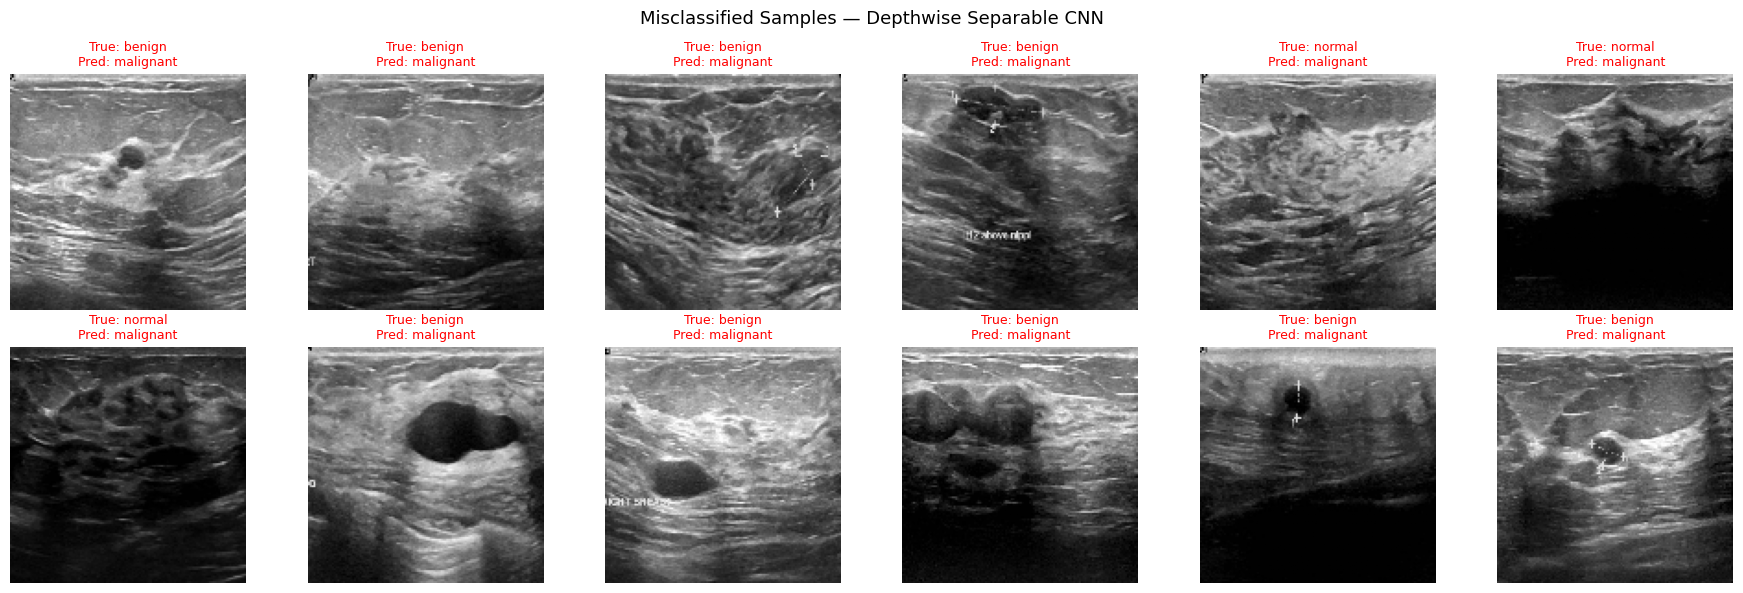

In [15]:
misclassified_idx = np.where(y_pred_b != y_test)[0]
n_show = min(12, len(misclassified_idx))

print(f"Total misclassified by DS-CNN: {len(misclassified_idx)} / {len(y_test)}")

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

for i, idx in enumerate(misclassified_idx[:n_show]):
    axes[i].imshow(X_test[idx])
    true_label  = classes[y_test[idx]]
    pred_label  = classes[y_pred_b[idx]]
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}",
                      fontsize=9,
                      color='red' if true_label != pred_label else 'green')
    axes[i].axis('off')

# Hide unused subplots
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Misclassified Samples — Depthwise Separable CNN', fontsize=13)
plt.tight_layout()
plt.savefig('misclassified_ds_cnn.png', dpi=150)
plt.show()

## Summary

| Feature | Baseline CNN | **Depthwise Separable CNN** |
|---|---|---|
| Conv layers | Standard `Conv2D` | `SeparableConv2D` (depthwise + pointwise) |
| Batch Normalisation | ✗ | ✓ (after each block) |
| Final spatial pooling | `Flatten` | `GlobalAveragePooling2D` |
| Parameter count | ~Higher | ~Lower (up to 8× fewer per layer) |
| Overfitting risk | Higher | Lower |
| Inference speed | Baseline | Faster |

**Key insight:** `SeparableConv2D` splits the job of a standard convolution into two cheaper operations — a spatial filter applied independently per channel (depthwise), followed by a 1×1 convolution to mix information across channels (pointwise). This dramatically cuts the parameter count and computation while preserving feature learning ability, making it ideal for small medical imaging datasets like BUSI.